# Exploration des données — Rapports de difficultés de service (FAA SDR)

## Objectif de ce notebook

Avant de construire une analyse ou un dashboard, on prend le temps de regarder à quoi ressemblent vraiment les données : combien de lignes, quelles colonnes, ce qu'elles contiennent, ce qui manque. Rien de compliqué ici — juste comprendre le terrain de jeu avant d'aller plus loin.

On commence par un seul fichier (l'année 2024) pour ne pas être noyé sous le volume, puis on élargira à toutes les années disponibles (2015-2026).

## 1. Chargement des librairies et d'un premier fichier

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Pour que pandas affiche toutes les colonnes sans les tronquer
pd.set_option("display.max_columns", 100)

df_2024 = pd.read_csv("../data/raw/SDR-2024.csv", low_memory=False)

print(f"Nombre de lignes  : {df_2024.shape[0]}")
print(f"Nombre de colonnes : {df_2024.shape[1]}")

Nombre de lignes  : 66074
Nombre de colonnes : 76


## 2. À quoi ressemble une ligne de données ?

Chaque ligne = un signalement de problème (une panne, un défaut constaté) remonté par une compagnie aérienne ou un atelier de maintenance à la FAA (l'autorité de l'aviation civile américaine).

In [2]:
df_2024.head(5)

,OperatorControlNumber,DifficultyDate,SubmissionDate,OperatorDesignator,SubmitterDesignator,SubmitterTypeCode,ReceivingRegionCode,ReceivingDistrictOffice,SDRType,JASCCode,NatureOfConditionA,NatureOfConditionB,NatureOfConditionC,PrecautionaryProcedureA,PrecautionaryProcedureB,PrecautionaryProcedureC,PrecautionaryProcedureD,StageOfOperationCode,HowDiscoveredCode,RegistryNNumber,AircraftMake,AircraftModel,AircraftSerialNumber,AircraftTotalTime,AircraftTotalCycles,EngineMake,EngineModel,EngineSerialNumber,EngineTotalTime,EngineTotalCycles,PropellerMake,PropellerModel,PropellerSerialNumber,PropellerTotalTime,PropellerTotalCycles,PartMake,PartName,PartNumber,PartSerialNumber,PartCondition,PartLocation,PartTotalTime,PartTotalCycles,PartTimeSince,PartSinceCode,ComponentMake,ComponentModel,ComponentName,ComponentPartNumber,ComponentSerialNumber,ComponentLocation,ComponentTotalTime,ComponentTotalCycles,ComponentTimeSince,ComponentSinceCode,FuselageStationFrom,FuselageStationTo,StringerFrom,StringerFromSide,StringerTo,StringerToSide,WingStationFrom,WingStationFromSide,WingStationTo,WingStationToSide,ButtLineFrom,ButtLineFromSide,ButtlineTo,ButtlineToSide,WaterLineFrom,WaterLineTo,CrackLength,NumberOfCracks,CorrosionLevel,StructuralOther,Discrepancy
0,DALA2024010200007,01/01/2024,2024-01-02T04:07:28.643-05:00,DALA,DALA,A,SO,27,A,3350,O,NaN,NaN,K,NaN,NaN,NaN,IN,O,329NW,AIRBUS,A320211,306,87175.0,40643.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN,UNKNOWN,NaN,UNKNOWN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SHIP 3229 DISC: FOUND BROKEN GROUND WIRE FOR E...
1,DALA2024010200010,01/01/2024,2024-01-02T04:07:29.257-05:00,DALA,DALA,A,SO,27,A,2565,O,NaN,NaN,K,NaN,NaN,NaN,IN,O,334NW,AIRBUS,A320212,339,90337.0,41431.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,UNKNOWN,UNKNOWN,NaN,UNKNOWN,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2L SLIDE DEPLOYED IN ERROR. C/A: REF. LOG 0134...
2,KCSA202401011000,01/01/2024,2024-01-01T23:54:58.103-05:00,KCSA,KCSA,A,GL,23,A,5320,O,NaN,NaN,K,NaN,NaN,NaN,IN,V,712CK,BOEING,7474B5F,26414,86171.0,15444.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ANGLE,UNKNOWN,NaN,CRACKED,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1820,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,178,NaN,NaN,1.0,NaN,NaN,"AFT CARGO DOOR, UPPER FORWARD CORNER AT BS. 18..."
3,2024FA0000000,01/02/2024,2024-01-02T10:46:53.440-05:00,NaN,NaN,B,SO,11,G,7120,O,NaN,NaN,O,NaN,NaN,NaN,NR,M,NaN,BOEING,737*,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BOEING,THRUST LINK,310A204110,NaN,MAKING METAL,ENGINE MOUNT,NaN,NaN,NaN,NaN,BOEING,NaN,THRUST LINK,310A204110,NaN,ENGINE MOUNT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,SURFACE INDICATION DISCOVERED DURING MAGNETIC ...
4,DXTA2024010210487,01/01/2024,2024-01-02T10:58:32.550-05:00,DXTA,DXTA,E,GL,7,A,3350,O,NaN,NaN,K,NaN,NaN,NaN,TX,C,832QS,TEXTRN,TEXTRON700,7000076,1576.0,897.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,BATTERY,CBS281,008489,FAILED,UNKNOWN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,EMERGENCY LIGHTS DO NOT ILLUMINATE WHEN PLACED...


## 3. Quelles sont les colonnes disponibles ?

In [3]:
list(df_2024.columns)

['OperatorControlNumber',
 'DifficultyDate',
 'SubmissionDate',
 'OperatorDesignator',
 'SubmitterDesignator',
 'SubmitterTypeCode',
 'ReceivingRegionCode',
 'ReceivingDistrictOffice',
 'SDRType',
 'JASCCode',
 'NatureOfConditionA',
 'NatureOfConditionB',
 'NatureOfConditionC',
 'PrecautionaryProcedureA',
 'PrecautionaryProcedureB',
 'PrecautionaryProcedureC',
 'PrecautionaryProcedureD',
 'StageOfOperationCode',
 'HowDiscoveredCode',
 'RegistryNNumber',
 'AircraftMake',
 'AircraftModel',
 'AircraftSerialNumber',
 'AircraftTotalTime',
 'AircraftTotalCycles',
 'EngineMake',
 'EngineModel',
 'EngineSerialNumber',
 'EngineTotalTime',
 'EngineTotalCycles',
 'PropellerMake',
 'PropellerModel',
 'PropellerSerialNumber',
 'PropellerTotalTime',
 'PropellerTotalCycles',
 'PartMake',
 'PartName',
 'PartNumber',
 'PartSerialNumber',
 'PartCondition',
 'PartLocation',
 'PartTotalTime',
 'PartTotalCycles',
 'PartTimeSince',
 'PartSinceCode',
 'ComponentMake',
 'ComponentModel',
 'ComponentName',
 'C

Il y a beaucoup de colonnes, et la plupart sont très techniques ou très rarement remplies (ex : les colonnes qui décrivent une position précise sur la structure de l'avion, utiles seulement pour des dommages structurels). Voici les colonnes qu'on va réellement utiliser, expliquées simplement :

| Colonne | Ce que ça veut dire |
|---|---|
| `OperatorControlNumber` | Numéro de dossier unique du signalement |
| `DifficultyDate` | Date à laquelle le problème a été constaté |
| `OperatorDesignator` | Code de la compagnie aérienne qui exploite l'avion |
| `JASCCode` | Code qui indique **quel système de l'avion** est concerné (moteur, freins, portes, train d'atterrissage...). C'est ce qu'on appelle un "chapitre ATA" dans l'aviation : une classification standard, utilisée par tous les avionneurs, qui découpe un avion en grandes familles de systèmes numérotées. |
| `NatureOfConditionA/B/C` | Nature du problème constaté (ex : fissure, corrosion, panne électrique...), sous forme de code |
| `AircraftMake` | Constructeur de l'avion (Airbus, Boeing, etc.) |
| `AircraftModel` | Modèle précis de l'avion (ex : `A320211` = une variante spécifique de l'A320) |
| `AircraftSerialNumber` | Numéro de série qui identifie un avion précis (permet de suivre le même appareil dans le temps) |
| `AircraftTotalTime` | Nombre d'heures de vol total de l'avion au moment du signalement — un indicateur d'usure/âge |
| `AircraftTotalCycles` | Nombre de cycles total de l'avion (1 cycle = 1 décollage + 1 atterrissage) — autre indicateur d'usure, souvent plus pertinent que les heures pour la fatigue mécanique des pièces |
| `PartName` / `PartCondition` | Nom et état de la pièce concernée, quand elle est identifiée |
| `Discrepancy` | Le texte libre écrit par le technicien : ce qui s'est passé et ce qui a été fait pour réparer. C'est notre matière première pour l'analyse de texte, plus tard. |

On regardera les autres colonnes plus tard, seulement si elles s'avèrent utiles.

## 4. Est-ce qu'il y a beaucoup de valeurs manquantes ?

Normal d'en avoir beaucoup : la plupart des colonnes ne concernent que certains types de signalements (par exemple, les colonnes sur la structure de l'avion ne sont remplies que pour des dommages structurels, qui sont rares).

In [4]:
pourcentage_manquant = (df_2024.isna().mean() * 100).sort_values(ascending=False)
pourcentage_manquant[pourcentage_manquant > 0].round(1)

PrecautionaryProcedureD    100.0
PropellerTotalCycles       100.0
PrecautionaryProcedureC     99.9
PropellerTotalTime          99.9
PropellerSerialNumber       99.9
                           ...  
AircraftSerialNumber         0.2
AircraftModel                0.1
AircraftMake                 0.1
PartName                     0.0
PartCondition                0.0
Length: 63, dtype: float64

## 5. Quels constructeurs sont présents dans les données ?

Important : ce fichier contient **tous les constructeurs**, pas seulement Airbus. Il va falloir filtrer.

In [5]:
df_2024["AircraftMake"].value_counts().head(15)

AircraftMake
BOEING    34968
AIRBUS    16563
CNDAIR     5186
EMB        4767
CESSNA      950
BOMBDR      799
DOUG        796
LKHEED      367
BOLKMS      227
TEXTRN      195
PIPER       182
BEECH       141
BELL        128
UROCOP      114
AEROSP       85
Name: count, dtype: int64

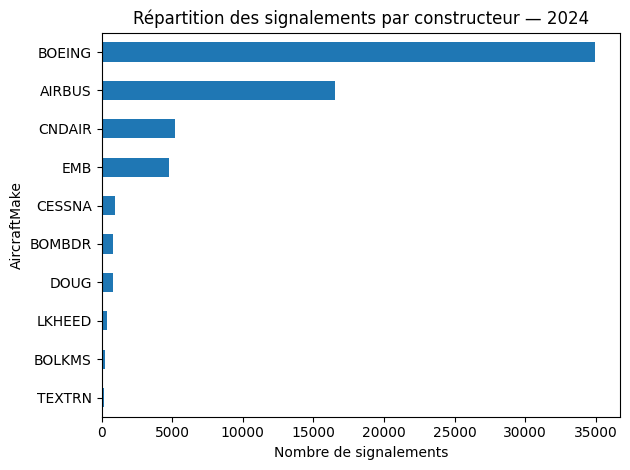

In [6]:
df_2024["AircraftMake"].value_counts().head(10).plot(kind="barh")
plt.xlabel("Nombre de signalements")
plt.title("Répartition des signalements par constructeur — 2024")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Zoom sur Airbus : quels modèles ?

In [7]:
df_airbus_2024 = df_2024[df_2024["AircraftMake"].str.contains("AIRBUS", case=False, na=False)]

part_airbus = len(df_airbus_2024) / len(df_2024) * 100
print(f"Signalements Airbus en 2024 : {len(df_airbus_2024)} sur {len(df_2024)} au total ({part_airbus:.1f}%)")

df_airbus_2024["AircraftModel"].value_counts().head(20)

Signalements Airbus en 2024 : 16563 sur 66074 au total (25.1%)


AircraftModel
A321231       1925
A320232       1794
A319114       1583
A319112       1204
BD5001A10      962
A321211        902
A320214        880
A319132        807
A300F4622R     588
A320212        560
BD5001A11      524
A321271N       459
A330323        417
A320271N       398
A300F4605R     378
A330243        339
A330941        327
A321253NX      313
A319131        285
A330223        216
Name: count, dtype: int64

On voit que `AircraftModel` détaille des variantes précises (`A320211`, `A320212`, `A321231`...) plutôt que juste "A320" ou "A321". Pour analyser par grande famille d'appareil, il faudra regrouper ces variantes. Petit aperçu de ce que ça donnerait :

In [8]:
familles = df_airbus_2024["AircraftModel"].str.extract(r"(A3[0-9]0)")[0]
familles.value_counts()

0
A320    3965
A330    1522
A300    1202
A350     148
A310       4
Name: count, dtype: int64

## 7. Vue d'ensemble sur toutes les années disponibles (2015-2026)

On assemble maintenant les 12 fichiers pour avoir une vision complète dans le temps.

In [9]:
import glob

fichiers = sorted(glob.glob("../data/raw/SDR-*.csv"))
print(f"{len(fichiers)} fichiers trouvés")

morceaux = []
for chemin in fichiers:
    annee = chemin.split("SDR-")[1].split(".csv")[0]
    tmp = pd.read_csv(chemin, low_memory=False)
    tmp["AnneeFichier"] = annee
    morceaux.append(tmp)

df_tout = pd.concat(morceaux, ignore_index=True)
print(f"Total : {df_tout.shape[0]} lignes, {df_tout.shape[1]} colonnes")

12 fichiers trouvés


Total : 717683 lignes, 77 colonnes


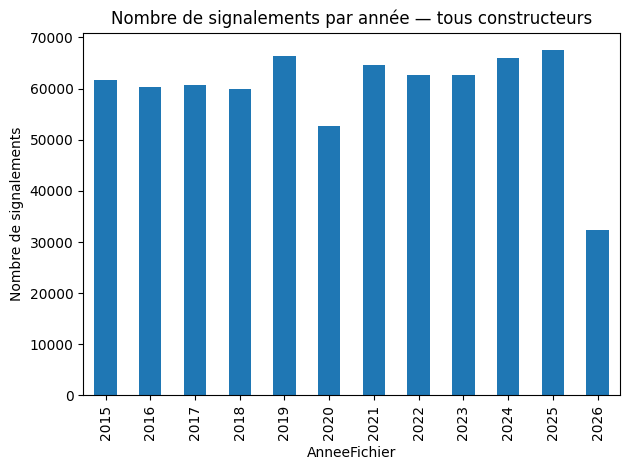

In [10]:
df_tout["AnneeFichier"].value_counts().sort_index().plot(kind="bar")
plt.ylabel("Nombre de signalements")
plt.title("Nombre de signalements par année — tous constructeurs")
plt.tight_layout()
plt.show()

⚠️ L'année 2026 est probablement incomplète (on est encore dans l'année en cours au moment de cette analyse) — il faudra en tenir compte pour ne pas comparer une année complète à une année partielle.

Signalements Airbus 2015-2026 : 140164 sur 717683 (19.5%)


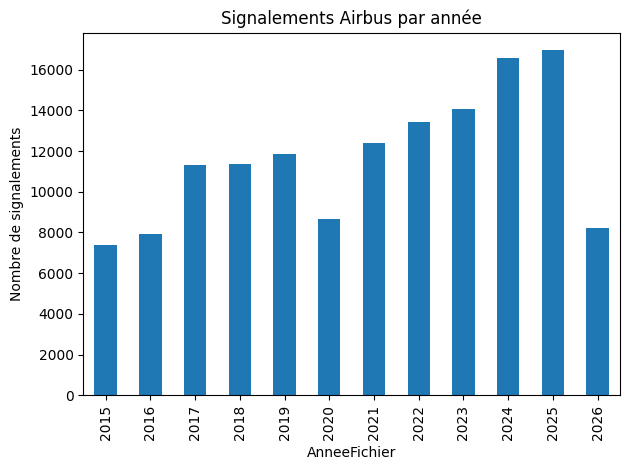

In [11]:
df_tout_airbus = df_tout[df_tout["AircraftMake"].str.contains("AIRBUS", case=False, na=False)]

part_airbus_totale = len(df_tout_airbus) / len(df_tout) * 100
print(f"Signalements Airbus 2015-2026 : {len(df_tout_airbus)} sur {len(df_tout)} ({part_airbus_totale:.1f}%)")

df_tout_airbus.groupby("AnneeFichier").size().plot(kind="bar")
plt.ylabel("Nombre de signalements")
plt.title("Signalements Airbus par année")
plt.tight_layout()
plt.show()

## 8. À quoi ressemble le texte libre (le narratif technique) ?

C'est la colonne `Discrepancy`, écrite par les techniciens eux-mêmes — donc pleine d'abréviations et de jargon de maintenance. Un aperçu de quelques exemples, sur les signalements Airbus 2024 :

In [12]:
for texte in df_airbus_2024["Discrepancy"].dropna().sample(3, random_state=1):
    print(texte)
    print("-" * 80)

DAMAGE FOUND IN HOLES ON MIDDLE HINGE. STEEL (14D) ALUMINIUM (12F, 13F, 15F).    OPEN
--------------------------------------------------------------------------------
SHIP 3219 DISC: DURING CCK AND WHILE ACCOMPLISHING REPETITIVE INSPECTIONS PER ER /A 522877-14, REV E, CORROSION WAS FOUND ON THE LWR EDGE OF FR20 BULKHEAD BETWEEN LWR STRGR AND Y=520, RHS. AT REV A, FINAL DTE COMPLETE. C/A: PER SECTION II OF 608253-14,REV A, ACCOMPLISH SECTION II INITIAL INSPECTION WITHIN 45,601 FC - TOTAL FROM A/C FIRST FLIGHT, OR WITHIN 2,282 FC FROM 14MAY24. REPEAT SECITON II INSPECITON WITH IN EVERY 3,670 FC AFTER INITIAL INSPECTION. (LP: 0342084)
--------------------------------------------------------------------------------
DURING A CHECK EMERGENCY LIGHT OPS TEST FOUND DOOR L3 EPSU (101WL3) INOP. R+R EPSU (101WL3) PER A350 AMM 33-51. SW LOAD COMPLIED WITH. OPS CK GOOD. (LP# 6642953)
--------------------------------------------------------------------------------


## Ce qu'on retient, et la suite

Ce premier passage sert uniquement à comprendre le terrain : le volume de données, les colonnes utiles, la part d'Airbus dans le total, et le style du texte libre.

Prochaines étapes possibles :
- Nettoyer et filtrer proprement le jeu de données pour ne garder qu'Airbus, avec les familles d'appareils bien regroupées (A320 / A330 / A350)
- Traduire les codes `JASCCode` en libellés compréhensibles ("chapitre ATA") pour savoir quel système est concerné à chaque fois
- Sauvegarder ce jeu de données nettoyé dans `data/processed/` pour ne pas avoir à répéter ce travail à chaque fois